# Data Exploration - Customer Churn Analysis

This notebook explores the customer churn dataset and provides insights for model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append('../src')
from data.data_loader import DataLoader
from data.validator import DataValidator
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
%matplotlib inline

## 1. Data Loading and Basic Information

In [99]:
# Dataset source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Load data
data_loader = DataLoader('../data/raw')
df = data_loader.load_training_data()
print(f"Dataset shape: {df.shape}")
print(f"Dataset info: ")
df.info()

Dataset shape: (7043, 21)
Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [100]:
# NOTE: Run this cell ONLY if you are working with the original dataset.
# If you are using synthetic data or other sources, do NOT run this cell
# as these transformations rely on specific columns and values from the dataset.

# Drop columns that are either identifiers or categorical with many unique values,
# which might not be useful or require special processing.
df = df.drop(columns=['customerID', 'MultipleLines', 'InternetService', 'PaymentMethod'])

# Convert 'gender' column from categorical text ('Female', 'Male') to numeric binary values.
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Map 'Contract' categorical column to ordinal integers.
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_mapping)

# Loop over all columns to convert 'Yes'/'No' string columns to 1/0 numeric format.
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].dropna().unique()
        if set(unique_vals) == {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

# Additional handling for columns containing 'Yes', 'No', and 'No internet service'.
# Map 'Yes' to 1, 'No' to 0, and 'No internet service' to -1 to differentiate this special case.
for col in df.select_dtypes(include='object'):
    unique_vals = set(df[col].dropna().unique())
    if unique_vals.issubset({'Yes', 'No', 'No internet service'}):
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': -1})

# Convert to float (with errors='coerce' to safely handle any bad entries)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [101]:
# Display first few rows
print("First 5 rows: ")
df.head()

First 5 rows: 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,29.85,29.85,0
1,0,0,0,0,34,1,1,0,1,0,0,0,1,0,56.95,1889.50,0
2,0,0,0,0,2,1,1,1,0,0,0,0,0,1,53.85,108.15,1
3,0,0,0,0,45,0,1,0,1,1,0,0,1,0,42.30,1840.75,0
4,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1


In [102]:
# Basic statistics
print("Descriptive Statistics: ")
df.describe()


Descriptive Statistics: 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.069999,0.128212,0.127219,0.073548,0.167684,0.171234,0.690473,0.592219,64.761692,2283.300441,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.706051,0.738369,0.737868,0.708201,0.756958,0.758507,0.833755,0.491457,30.090047,2266.771362,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,401.450000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,118.750000,8684.800000,1.000000


## 2. Data Quality Assessment

In [105]:
# Check for missing values
print("Missing Values: ")
missing_stats = df.isnull().sum()
missing_pct = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
        'Missing Count': missing_stats,
        'Missing Percentage': missing_pct,
    })
print(missing_df[missing_df['Missing Count'] > 0])
    
if missing_df['Missing Count'].sum() == 0:
    print("No missing values found!")

Missing Values: 
              Missing Count  Missing Percentage
TotalCharges             11            0.156183


In [106]:
df = df.dropna(subset=['TotalCharges'])

In [109]:
# Check for duplicates\n",
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 35
Percentage of duplicates: 0.50%


In [110]:
# Data validation report
validator = DataValidator()
validation_report = validator.generate_report(df)
print(f"Overall validation status: {validation_report['overall_status']}")
print(f"Summary statistics: ")
for key, value in validation_report['summary_statistics'].items():
    print(f"{key}: {value}")

Overall validation status: FAILED
Summary statistics: 
total_rows: 7032
total_columns: 17
missing_values: 0
duplicate_rows: 35
memory_usage_mb: 0.9656982421875


## 3. Target Variable Analysis

Churn Distribution:
No Churn (0): 5163 (73.4%)
Churn (1): 1869 (26.6%)


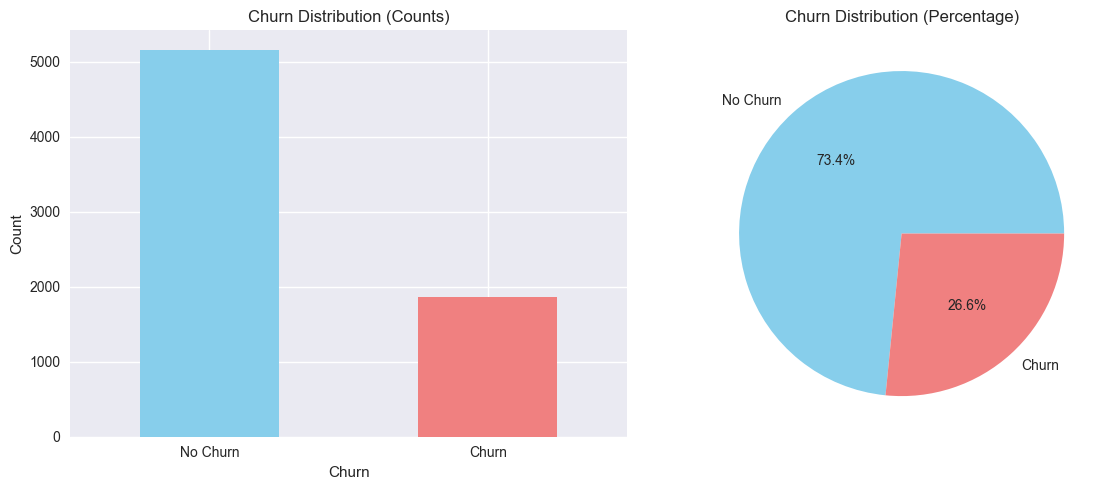

In [111]:
# Analyze target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Churn Distribution:")
print(f"No Churn (0): {churn_counts.iloc[0]} ({churn_pct.iloc[0]:.1f}%)")
print(f"Churn (1): {churn_counts.iloc[1]} ({churn_pct.iloc[1]:.1f}%)")
      
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
churn_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
ax1.set_title('Churn Distribution (Counts)')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Pie chart
ax2.pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
ax2.set_title('Churn Distribution (Percentage)')
plt.tight_layout()
plt.show()

## 4. Feature Analysis

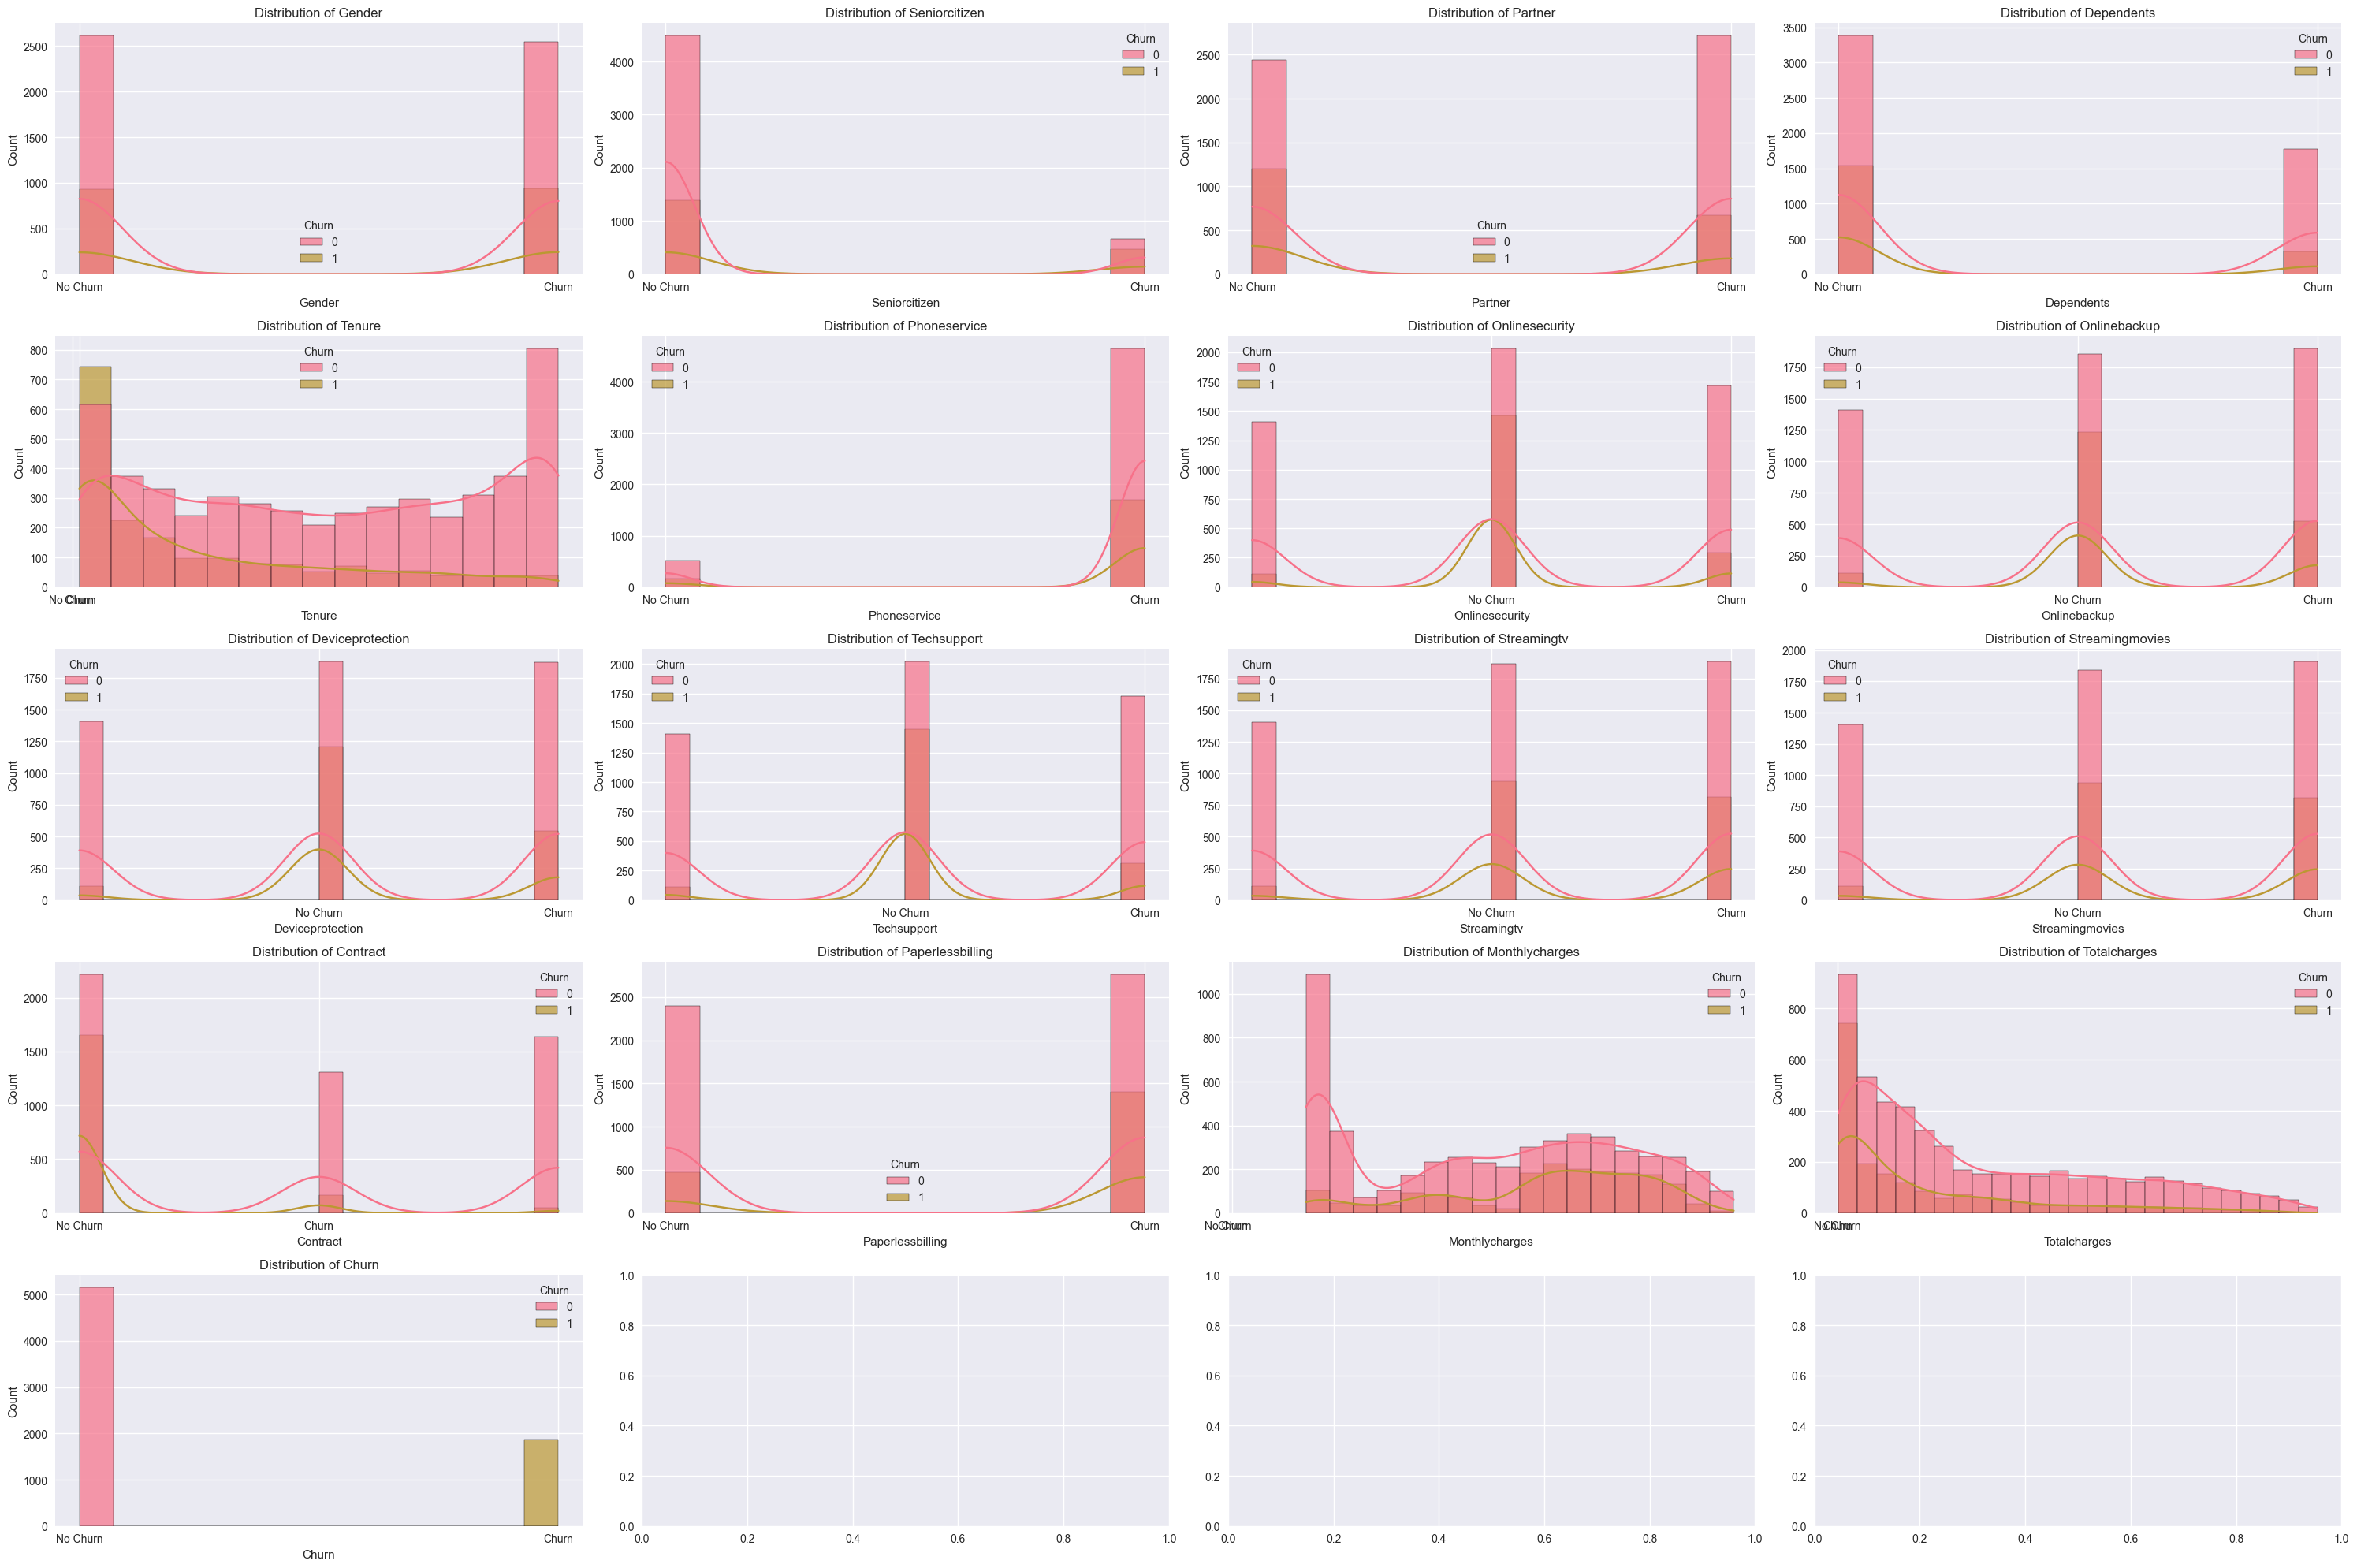

In [112]:
# Analyze numerical features
numerical_features = [i for i in df.columns]
fig, axes = plt.subplots(5, 4, figsize=(30, 20))
axes = axes.ravel()
for i, feature in enumerate(numerical_features):
    # Distribution plot
    sns.histplot(data=df, x=feature, hue='Churn', kde=True, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

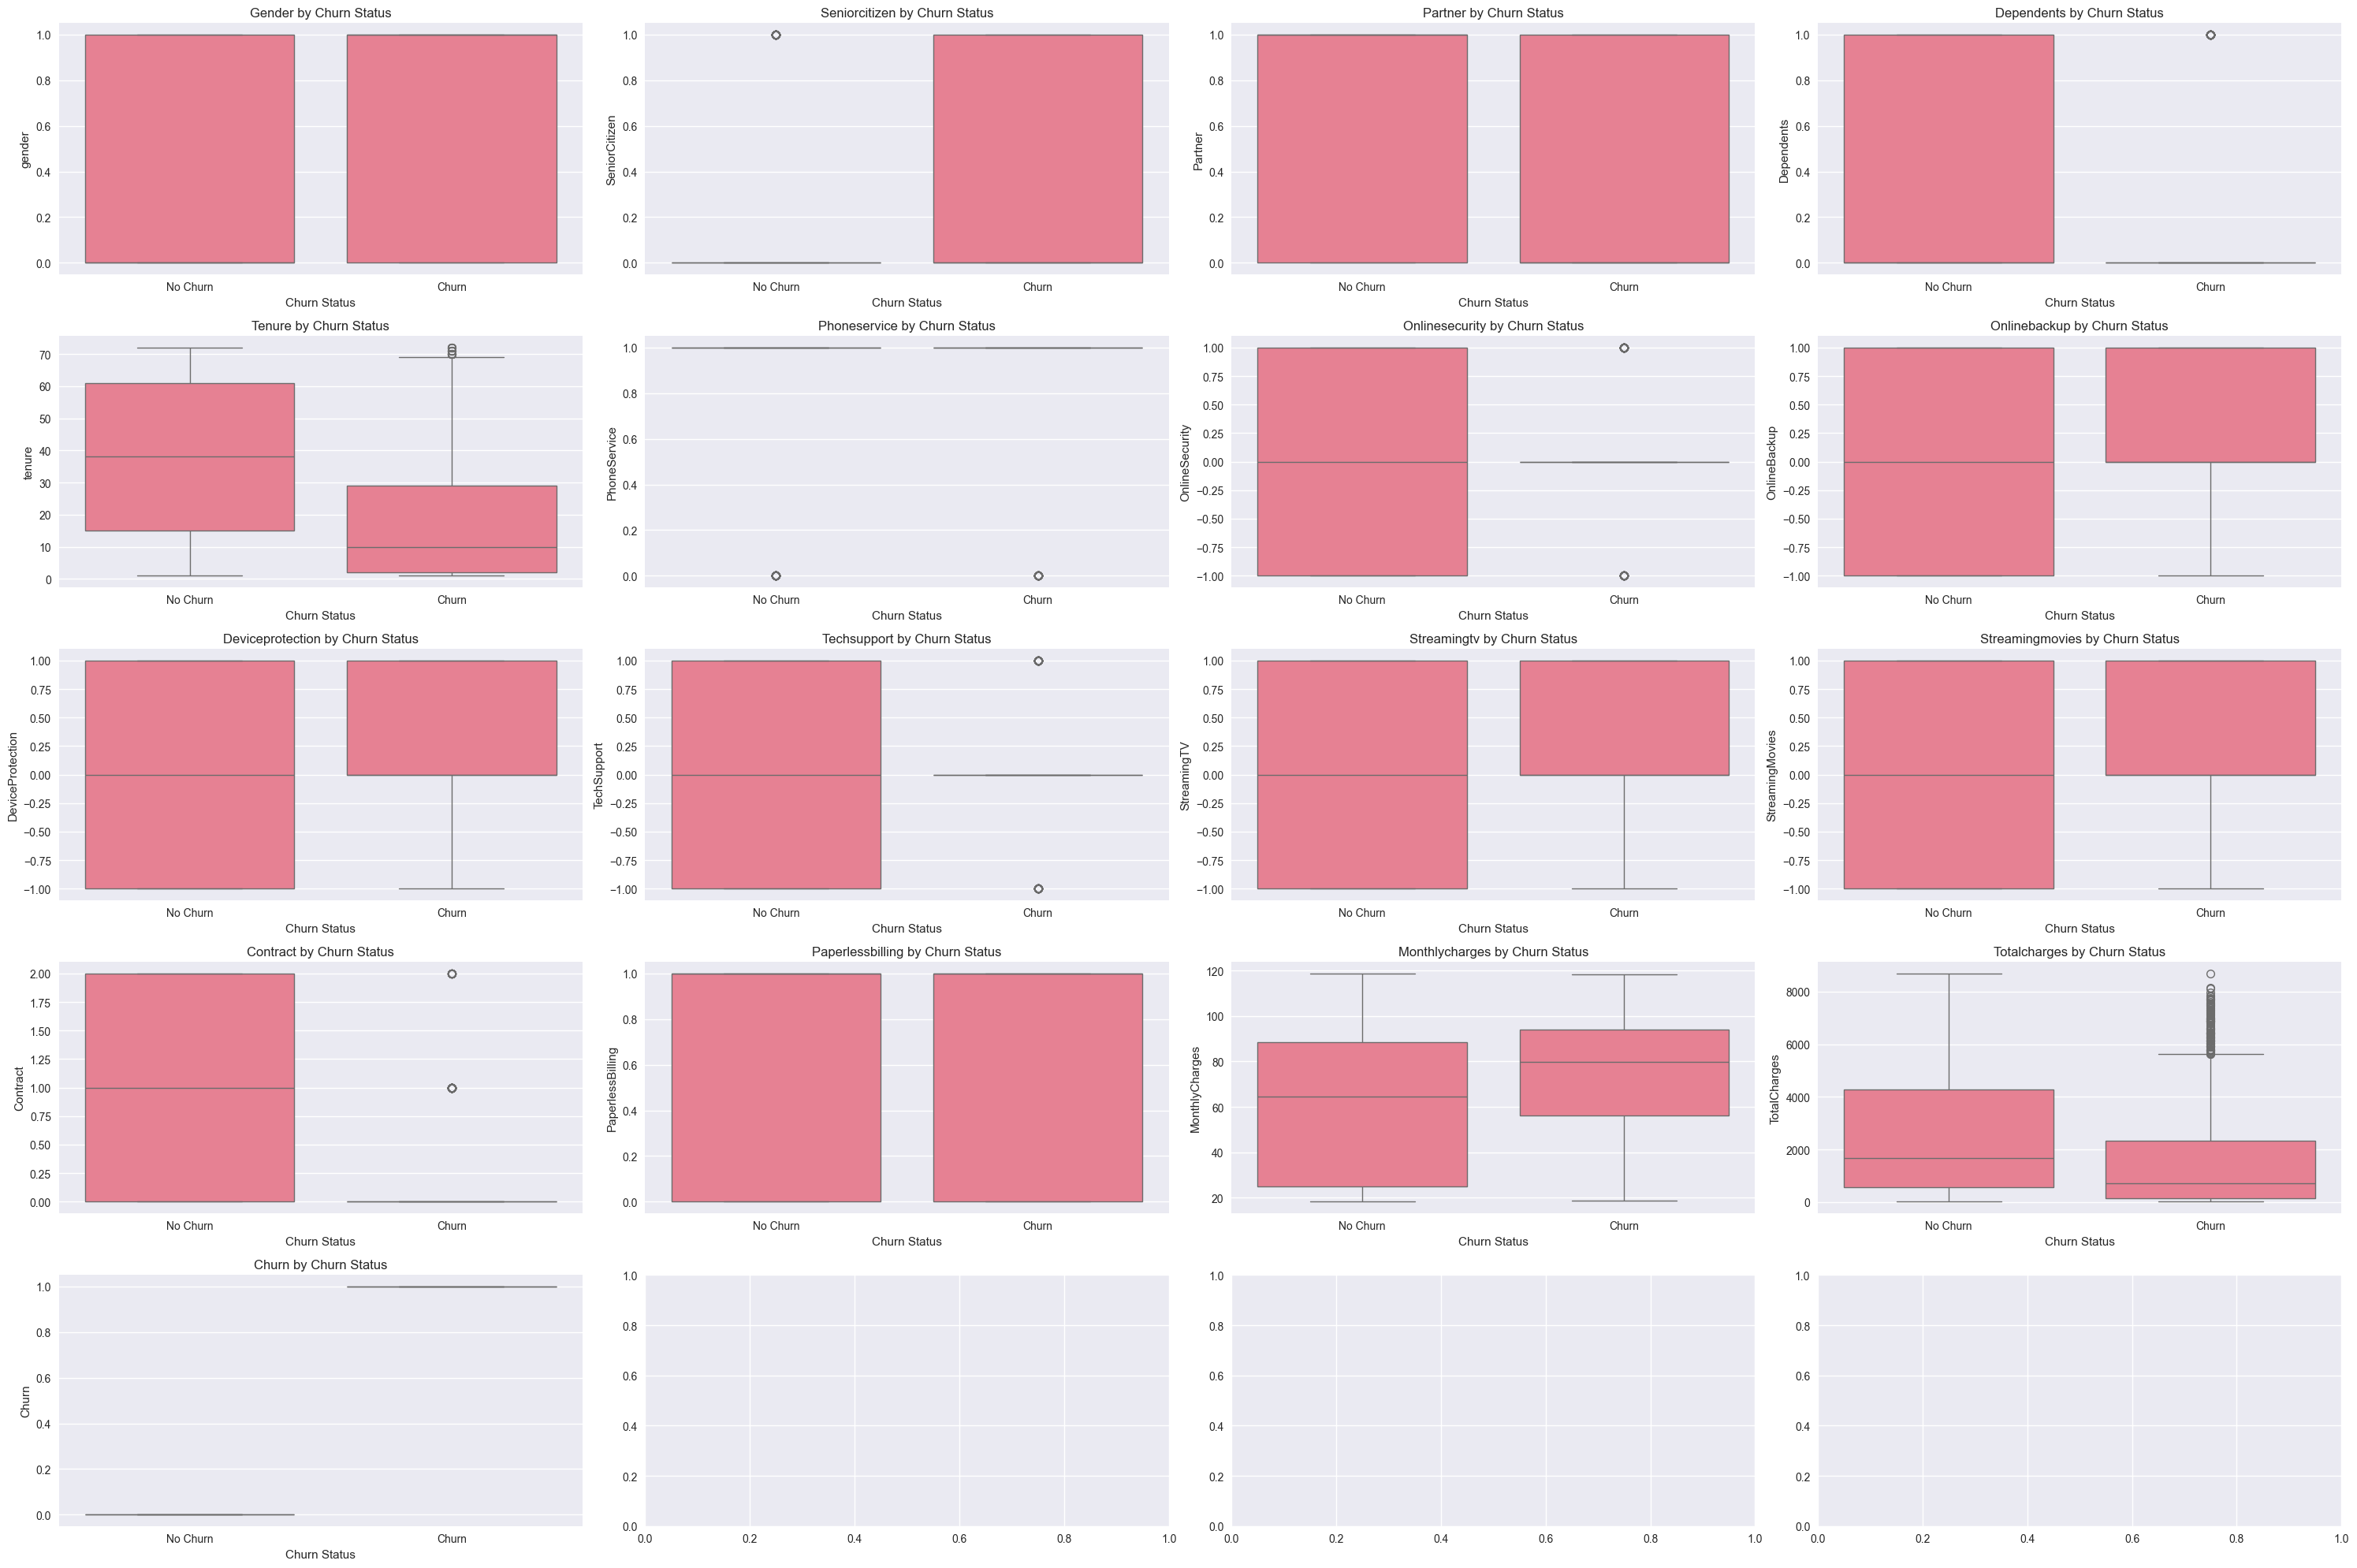

In [113]:
# Box plots for numerical features by churn
fig, axes = plt.subplots(5, 4, figsize=(30, 20))
axes = axes.ravel()
for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x='Churn', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature.replace("_", "").title()} by Churn Status')
    axes[i].set_xlabel('Churn Status')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [114]:
# Statistical comparison by churn status
print("Feature Statistics by Churn Status: ")
print("=" * 50)
      
for feature in numerical_features:
    no_churn_stats = df[df['Churn'] == 0][feature].describe()
    churn_stats = df[df['Churn'] == 1][feature].describe()

    print(f"\n{feature.replace('_', ' ').title()}: ")
    print(f"No Churn - Mean: {no_churn_stats['mean']:.2f}, Std: {no_churn_stats['std']:.2f}")
    print(f"Churn - Mean: {churn_stats['mean']:.2f}, Std: {churn_stats['std']:.2f}")

    # Calculate percentage difference
    if no_churn_stats['mean'] != 0:
        pct_diff = ((churn_stats['mean'] - no_churn_stats['mean']) / no_churn_stats['mean']) * 100
        print(f"Difference: {pct_diff:+.1f}%")
    else:
        print("Difference: N/A (division by zero)")

Feature Statistics by Churn Status: 

Gender: 
No Churn - Mean: 0.49, Std: 0.50
Churn - Mean: 0.50, Std: 0.50
Difference: +2.0%

Seniorcitizen: 
No Churn - Mean: 0.13, Std: 0.34
Churn - Mean: 0.25, Std: 0.44
Difference: +97.4%

Partner: 
No Churn - Mean: 0.53, Std: 0.50
Churn - Mean: 0.36, Std: 0.48
Difference: -32.2%

Dependents: 
No Churn - Mean: 0.34, Std: 0.47
Churn - Mean: 0.17, Std: 0.38
Difference: -49.2%

Tenure: 
No Churn - Mean: 37.65, Std: 24.08
Churn - Mean: 17.98, Std: 19.53
Difference: -52.2%

Phoneservice: 
No Churn - Mean: 0.90, Std: 0.30
Churn - Mean: 0.91, Std: 0.29
Difference: +0.9%

Onlinesecurity: 
No Churn - Mean: 0.06, Std: 0.78
Churn - Mean: 0.10, Std: 0.46
Difference: +60.6%

Onlinebackup: 
No Churn - Mean: 0.10, Std: 0.79
Churn - Mean: 0.22, Std: 0.54
Difference: +128.8%

Deviceprotection: 
No Churn - Mean: 0.09, Std: 0.79
Churn - Mean: 0.23, Std: 0.55
Difference: +156.1%

Techsupport: 
No Churn - Mean: 0.06, Std: 0.78
Churn - Mean: 0.11, Std: 0.46
Difference:

## 5. Correlation Analysis

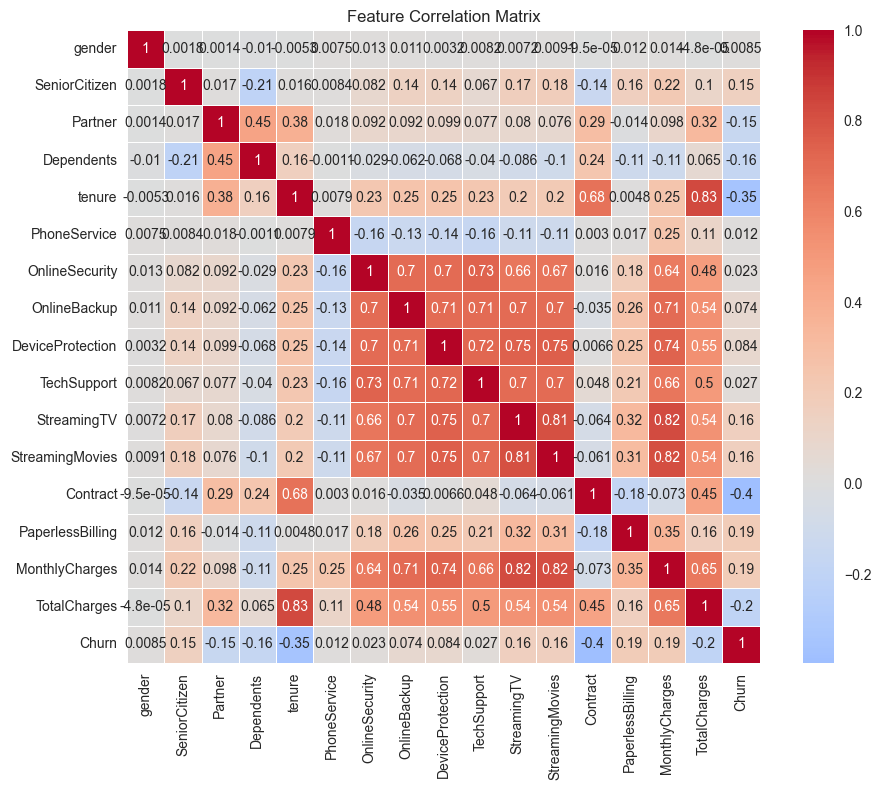

Correlation with Churn:
Contract: -0.396
Tenure: -0.354
Totalcharges: -0.199
Monthlycharges: 0.193
Paperlessbilling: 0.191
Streamingtv: 0.165
Dependents: -0.163
Streamingmovies: 0.163
Seniorcitizen: 0.151
Partner: -0.150
Deviceprotection: 0.084
Onlinebackup: 0.074
Techsupport: 0.027
Onlinesecurity: 0.023
Phoneservice: 0.012
Gender: 0.009


In [116]:
# Correlation matrix
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation with target\n",
print("Correlation with Churn:")
target_corr = correlation_matrix['Churn'].sort_values(key=abs, ascending=False)
for feature, corr in target_corr.items():
    if feature != 'Churn':
        print(f"{feature.replace('_', ' ').title()}: {corr:.3f}")

## 6. Outlier Detection

In [117]:
# Outlier detection using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

print("Outlier Analysis:")
print("=" * 30)
outlier_summary = []

for feature in numerical_features:
    outliers = detect_outliers_iqr(df[feature])
    outlier_count = outliers.sum()
    outlier_pct = (outlier_count / len(df)) * 100\

    outlier_summary.append({
        'Feature': feature.replace('_', ' ').title(),
        'Outlier Count': outlier_count,
        'Outlier Percentage': f"{outlier_pct:.1f}%"
    })
    print(f"{feature.replace('_', ' ').title()}: {outlier_count} outliers ({outlier_pct:.1f}%)")
              
outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Summary: ")
print(outlier_df)

Outlier Analysis:
Gender: 0 outliers (0.0%)
Seniorcitizen: 1142 outliers (16.2%)
Partner: 0 outliers (0.0%)
Dependents: 0 outliers (0.0%)
Tenure: 0 outliers (0.0%)
Phoneservice: 680 outliers (9.7%)
Onlinesecurity: 0 outliers (0.0%)
Onlinebackup: 0 outliers (0.0%)
Deviceprotection: 0 outliers (0.0%)
Techsupport: 0 outliers (0.0%)
Streamingtv: 0 outliers (0.0%)
Streamingmovies: 0 outliers (0.0%)
Contract: 0 outliers (0.0%)
Paperlessbilling: 0 outliers (0.0%)
Monthlycharges: 0 outliers (0.0%)
Totalcharges: 0 outliers (0.0%)
Churn: 0 outliers (0.0%)
Outlier Summary: 
             Feature  Outlier Count Outlier Percentage
0             Gender              0               0.0%
1      Seniorcitizen           1142              16.2%
2            Partner              0               0.0%
3         Dependents              0               0.0%
4             Tenure              0               0.0%
5       Phoneservice            680               9.7%
6     Onlinesecurity              0          

## 7. Feature Engineering Insights

In [ ]:
# NOTE: This cell should only be used if you're using the synthetic data 

# Create derived features for analysis
df_analysis = df.copy()

# Average monthly charges per tenure month
df_analysis['avg_monthly_charges'] = df_analysis['monthly_charges'] / (df_analysis['tenure'] + 1)

# Charges per month based on total charges
df_analysis['charges_per_month'] = df_analysis['total_charges'] / (df_analysis['tenure'] + 1)

# Binary features
df_analysis['is_senior'] = (df_analysis['age'] > 65).astype(int)
df_analysis['is_new_customer'] = (df_analysis['tenure'] <= 12).astype(int)
df_analysis['high_charges'] = (df_analysis['monthly_charges'] > df_analysis['monthly_charges'].median()).astype(int)

# Analyze new features
new_features = ['avg_monthly_charges', 'charges_per_month', 'is_senior', 'is_new_customer', 'high_charges']

print("New Feature Analysis: ")
print("=" * 40)

for feature in new_features:
    if feature.startswith('is_') or feature == 'high_charges':
        # Binary feature analysis
        churn_rate_0 = df_analysis[df_analysis[feature] == 0]['Churn'].mean()
        churn_rate_1 = df_analysis[df_analysis[feature] == 1]['Churn'].mean()
        print(f"\n{feature.replace('_', ' ').title()}:")
        print(f"Churn rate when {feature} = 0: {churn_rate_0:.1%}")
        print(f"Churn rate when {feature} = 1: {churn_rate_1:.1%}")
        print(f"Difference: {churn_rate_1 - churn_rate_0:+.1%}")
    else:
       # Continuous feature analysis
       corr_with_churn = df_analysis[feature].corr(df_analysis['Churn'])
       print(f"\n{feature.replace('_', ' ').title()}:")
       print(f"Correlation with churn: {corr_with_churn:.3f}")

In [118]:
# NOTE: Use this cell ONLY if you're working with the Telco Customer Churn dataset 
# All columns should be numeric already.

df_analysis = df.copy()

# Derived continuous features
df_analysis['avg_monthly_charges'] = df_analysis['MonthlyCharges'] / (df_analysis['tenure'] + 1)
df_analysis['charges_per_month'] = df_analysis['TotalCharges'] / (df_analysis['tenure'] + 1)

# Derived binary features
df_analysis['is_senior'] = df_analysis['SeniorCitizen']
df_analysis['is_new_customer'] = (df_analysis['tenure'] <= 12).astype(int)
df_analysis['high_charges'] = (df_analysis['MonthlyCharges'] > df_analysis['MonthlyCharges'].median()).astype(int)

# New features to analyze
new_features = ['avg_monthly_charges', 'charges_per_month', 'is_senior', 'is_new_customer', 'high_charges']

print("New Feature Analysis:")
print("=" * 40)

for feature in new_features:
    if feature.startswith('is_') or feature == 'high_charges':
        # Binary features - compare churn rate
        churn_rate_0 = df_analysis[df_analysis[feature] == 0]['Churn'].mean()
        churn_rate_1 = df_analysis[df_analysis[feature] == 1]['Churn'].mean()
        
        print(f"\n{feature.replace('_', ' ').title()}:")
        print(f"Churn rate when {feature} = 0: {churn_rate_0:.1%}")
        print(f"Churn rate when {feature} = 1: {churn_rate_1:.1%}")
        print(f"Difference: {churn_rate_1 - churn_rate_0:+.1%}")
    else:
        # Continuous features - correlation with Churn
        corr_with_churn = df_analysis[feature].corr(df_analysis['Churn'])
        
        print(f"\n{feature.replace('_', ' ').title()}:")
        print(f"Correlation with churn: {corr_with_churn:.3f}")


New Feature Analysis:

Avg Monthly Charges:
Correlation with churn: 0.424

Charges Per Month:
Correlation with churn: 0.071

Is Senior:
Churn rate when is_senior = 0: 23.7%
Churn rate when is_senior = 1: 41.7%
Difference: +18.0%

Is New Customer:
Churn rate when is_new_customer = 0: 17.1%
Churn rate when is_new_customer = 1: 47.7%
Difference: +30.5%

High Charges:
Churn rate when high_charges = 0: 18.0%
Churn rate when high_charges = 1: 35.2%
Difference: +17.3%


## 8. Data Distribution Analysis

Distribution Analysis: 


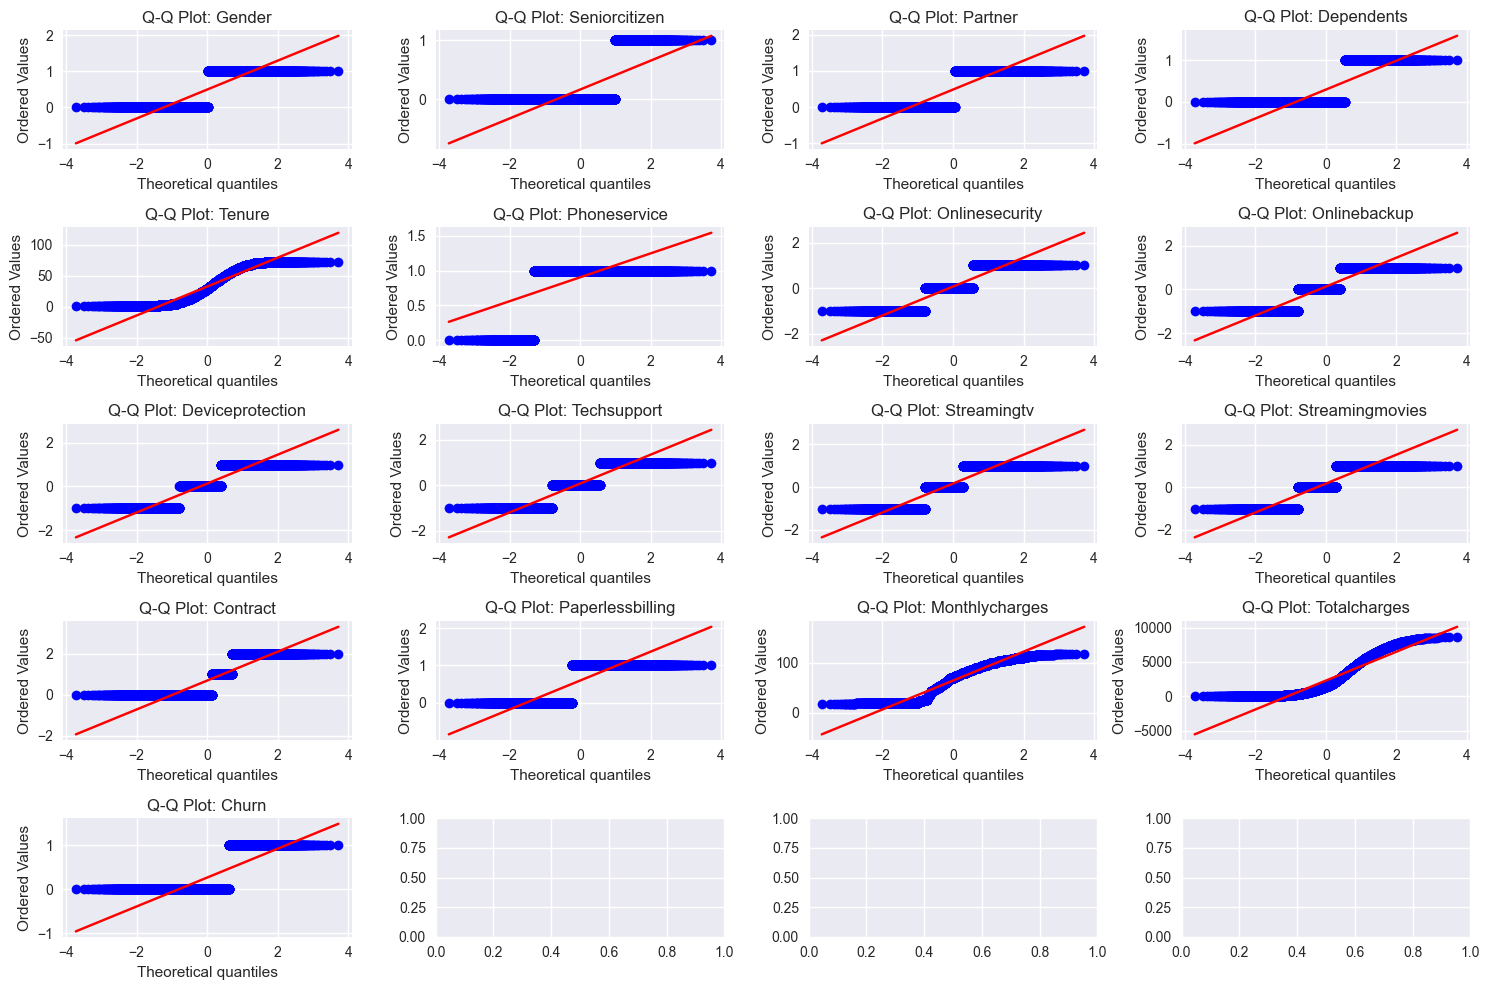

Distribution Statistics:
             Feature Skewness Kurtosis  Distribution
0             Gender    0.019   -2.000        Normal
1      Seniorcitizen    1.831    1.352  Right-skewed
2            Partner    0.070   -1.995        Normal
3         Dependents    0.881   -1.224  Right-skewed
4             Tenure    0.238   -1.388        Normal
5       Phoneservice   -2.729    5.448   Left-skewed
6     Onlinesecurity   -0.100   -0.991        Normal
7       Onlinebackup   -0.208   -1.146        Normal
8   Deviceprotection   -0.206   -1.144        Normal
9        Techsupport   -0.106   -1.003        Normal
10       Streamingtv   -0.290   -1.208        Normal
11   Streamingmovies   -0.298   -1.212        Normal
12          Contract    0.635   -1.266  Right-skewed
13  Paperlessbilling   -0.377   -1.858        Normal
14    Monthlycharges   -0.222   -1.256        Normal
15      Totalcharges    0.961   -0.232  Right-skewed
16             Churn    1.060   -0.876  Right-skewed


In [119]:
# Analyze distributions and skewness
from scipy import stats

print("Distribution Analysis: ")
print("=" * 30)

fig, axes = plt.subplots(5, 4, figsize=(15, 10))
axes = axes.ravel()

distribution_stats = []

for i, feature in enumerate(numerical_features):
    # Calculate skewness and kurtosis
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature])

    distribution_stats.append({
        'Feature': feature.replace('_', ' ').title(),
        'Skewness': f"{skewness:.3f}",
        'Kurtosis': f"{kurtosis:.3f}",
        'Distribution': 'Normal' if abs(skewness) < 0.5 else ('Right-skewed' if skewness > 0 else 'Left-skewed')
    })

    # Q-Q plot
    stats.probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {feature.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

# Display distribution statistics
dist_df = pd.DataFrame(distribution_stats)
print("Distribution Statistics:")
print(dist_df)

## 9. Key Insights and Recommendations

In [120]:
# Generate insights based on analysis\n",
insights = []

# Target variable balance
churn_rate = df['Churn'].mean()
if churn_rate < 0.1 or churn_rate > 0.9:
    insights.append(f"Dataset is imbalanced (churn rate: {churn_rate:.1%}). Consider sampling techniques.")
else:
    insights.append(f"Dataset is reasonably balanced (churn rate: {churn_rate:.1%}).")

# Missing values
if df.isnull().sum().sum() == 0:
    insights.append("No missing values detected in the dataset.")
else:
    insights.append(f"Missing values detected. Implement imputation strategy.")

# Outliers
total_outliers = sum([detect_outliers_iqr(df[feature]).sum() for feature in numerical_features])
outlier_pct = (total_outliers / (len(df) * len(numerical_features))) * 100
if outlier_pct > 5:
    insights.append(f"High outlier rate ({outlier_pct:.1f}%). Consider outlier treatment.")
else:
    insights.append(f"Outlier rate is acceptable ({outlier_pct:.1f}%).")

# Feature correlations
high_corr_pairs = []
corr_matrix = df[numerical_features].corr()
for i in range(len(numerical_features)):
    for j in range(i+1, len(numerical_features)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((numerical_features[i], numerical_features[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    insights.append(f"High correlation detected between features. Consider feature selection.")
else:
    insights.append("No high correlation between features detected.")

# Most predictive features\n",
target_corr = df[numerical_features].corr()['Churn'].abs().sort_values(ascending=False)
top_feature = target_corr.index[1]  # Exclude 'churn' itself
insights.append(f"Most predictive feature: {top_feature.replace('_', ' ').title()} (correlation: {target_corr[top_feature]:.3f})")

print("Key Insights and Recommendations:")
print("=" * 50)
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

Key Insights and Recommendations:
1. Dataset is reasonably balanced (churn rate: 26.6%).
2. No missing values detected in the dataset.
3. Outlier rate is acceptable (1.5%).
4. High correlation detected between features. Consider feature selection.
5. Most predictive feature: Contract (correlation: 0.396)


## 10. Data Export for Model Development

In [122]:
# Save insights and statistics for later use
exploration_summary = {
    'dataset_shape': df.shape,
    'churn_rate': churn_rate,
    'missing_values': df.isnull().sum().to_dict(),
    'feature_correlations': df[numerical_features].corr()['Churn'].to_dict(),
    'outlier_counts': {feature: detect_outliers_iqr(df[feature]).sum() for feature in numerical_features},
    'distribution_stats': {feature: {'skewness': stats.skew(df[feature]), 'kurtosis': stats.kurtosis(df[feature])} for feature in numerical_features}
    }

# Save to file
import json
with open('../data/processed/exploration_summary.json', 'w') as f:
    json.dump(exploration_summary, f, indent=2, default=str)

print("Exploration summary saved to '../data/processed/exploration_summary.json'")
print("Data exploration completed! Ready for model development.")

Exploration summary saved to '../data/processed/exploration_summary.json'
Data exploration completed! Ready for model development.
